# 04 · Compare flux across the four time-lag variants

How much does the time-lag setting alone change the flux? Each analyzer's raw
data is processed four times, varying only how the N2O / CH4 time lag is found
(see [processing versions](../docs/processing-versions.md)):

- `*-1` open covariance maximization (-1 to 10 s, no default)
- `*-2R` covariance maximization with a default fallback
- `*-3` constant lag
- `*-4` PWB

Everything else (site, period, raw signal, all other EddyPro settings) is held
fixed, so any difference in the resulting flux is attributable to the lag
setting. This notebook quantifies that difference.

## What makes the comparison fair

- **Paired by half-hour.** The four variants share the same raw data, so the
  comparison is paired: for every timestamp we have four fluxes that differ only
  in the lag. We treat them as matched pairs, not as four independent samples.
- **Common samples only.** A variant can fail to return a flux for a given
  half-hour (for example the open search `*-1` finding no clear covariance
  maximum). Comparing variants over different sets of half-hours would confound
  the lag effect with differing coverage, so we keep only the half-hours where
  **all four** variants produced a finite flux. Every metric below is computed on
  this common set, so all variants see exactly the same timestamps.
- **Within analyzer only.** QCL (2021_1) and LGR (2021_2) are different
  campaigns covering different periods. Each analyzer is compared on its own; QCL
  and LGR half-hours are never pooled.
- **Reference for interpretation.** Differences are also expressed against a
  reference variant (`*-2R`, the conventional covariance maximization with a
  default fallback). This is only a vantage point for reading the bias and the
  regression slope; the per-variant distributions and the cumulative budget show
  all four variants side by side and do not depend on the choice.

Three complementary views:

1. **Distribution and budget.** Mean, median, and spread of the flux per variant
   on the common set, plus the cumulative sum (the overall budget), which answers
   directly how the lag setting shifts the total flux.
2. **Paired difference vs reference.** Mean bias, RMSD, and the slope of an
   ordinary-least-squares fit. The slope is the multiplicative change in flux
   magnitude, the most compact summary of a systematic lag effect.
3. **Regression scatter** of each variant against the reference, with the 1:1
   line, to see whether the lag setting scales the flux, adds scatter, or both.

A note on what is *not* filtered: we keep every half-hour where all four fluxes
exist, with no extra quality-flag screen (the flags are not in the column
subsets). A stricter comparison could apply the same QC filter to all four
variants; that would change the absolute numbers but not the paired logic.

## Imports

In [1]:
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from diive.core.io.files import load_parquet

NB_START = datetime.now()  # notebook start time (reported in the last cell)

## Configuration

In [2]:
# Inputs: the per-variant flux column subsets from notebook 02. All four variants
# per analyzer now carry fluxes, including the PWB *-4 variant.
SUBSETDIR = Path("../data/02-eddypro_fluxes_level-1_parquet_subsets")
FIGDIR = Path("../figures")
TABDIR = Path("../tables")
FIGDIR.mkdir(parents=True, exist_ok=True)
TABDIR.mkdir(parents=True, exist_ok=True)

# Analysis year (the subsets are already restricted to 2021 in notebook 02).
YEAR = 2021

# The four time-lag variants per analyzer. QCL (campaign 2021_1) and LGR
# (campaign 2021_2) cover different periods, so each analyzer is compared on its
# own; we never mix QCL and LGR half-hours.
ANALYZERS = {
    "QCL": ["QCL-1", "QCL-2R", "QCL-3", "QCL-4"],
    "LGR": ["LGR-1", "LGR-2R", "LGR-3", "LGR-4"],
}

# Reference variant (suffix): covariance maximization with a default fallback,
# the conventional operational EddyPro setting. The other strategies (open search
# -1, constant lag -3, PWB -4) are read relative to it. Change this one constant
# to re-reference; the per-variant summaries and the cumulative budget below are
# reference-free and do not depend on it.
REF_SUFFIX = "2R"

# Fluxes to compare, per gas.
GASES = {"N2O": "FN2O", "CH4": "FCH4"}

# Load the four flux subsets per analyzer, restricted to YEAR.
data = {}
for codes in ANALYZERS.values():
    for code in codes:
        df = load_parquet(filepath=str(SUBSETDIR / f"{code}.parquet"))
        data[code] = df.loc[df.index.year == YEAR]
        print(f"{code}: {data[code].shape[0]} rows")

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-1.parquet (0.037 seconds).

QCL-1: 9632 rows


> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-2R.parquet (0.003 seconds).

QCL-2R: 9632 rows


> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-3.parquet (0.003 seconds).

...

LGR-2R: 7803 rows


> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-3.parquet (0.003 seconds).

LGR-3: 7803 rows


> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-4.parquet (0.004 seconds).

LGR-4: 7803 rows


## Build the paired, common-sample sets

For each analyzer and gas, line up the one gas flux across the four variants on
the timestamp index and keep only the half-hours where every variant has a finite
value. This common set is the fair comparison set used everywhere below.

In [3]:
def paired_common(codes, fluxvar):
    # Align one gas flux across the variants and keep only timestamps where every
    # variant has a finite flux (the fair, paired comparison set).
    frame = pd.DataFrame({code: data[code][fluxvar] for code in codes})
    common = frame.dropna(how="any")
    return frame, common


common_sets = {}
for analyzer, codes in ANALYZERS.items():
    for gas, fluxvar in GASES.items():
        frame, common = paired_common(codes, fluxvar)
        common_sets[(analyzer, gas)] = common
        print(f"\n=== {analyzer} {gas} ({fluxvar}) ===")
        for code in codes:
            print(f"  {code}: {int(frame[code].notna().sum())} valid")
        print(f"  common to all {len(codes)}: {common.shape[0]} "
              f"({100 * common.shape[0] / frame.shape[0]:.1f}% of {frame.shape[0]} timestamps)")


=== QCL N2O (FN2O) ===
  QCL-1: 9452 valid
  QCL-2R: 9452 valid
  QCL-3: 9452 valid
  QCL-4: 9455 valid
  common to all 4: 9451 (98.1% of 9632 timestamps)

=== QCL CH4 (FCH4) ===
  QCL-1: 9452 valid
  QCL-2R: 9452 valid
  QCL-3: 9452 valid
  QCL-4: 9455 valid
  common to all 4: 9451 (98.1% of 9632 timestamps)

=== LGR N2O (FN2O) ===
  LGR-1: 7729 valid
  LGR-2R: 7729 valid
  LGR-3: 7729 valid
  LGR-4: 7727 valid
  common to all 4: 7727 (99.0% of 7803 timestamps)

=== LGR CH4 (FCH4) ===
  LGR-1: 7729 valid
  LGR-2R: 7729 valid
  LGR-3: 7729 valid
  LGR-4: 7727 valid
  common to all 4: 7727 (99.0% of 7803 timestamps)


## Summary statistics per variant

Mean, median, spread, and the summed flux (the overall budget) for each variant
on the common set. The last two columns express the mean and the budget relative
to the reference variant. For near-zero mean fluxes the percentage is unstable;
the regression slope below is the more robust summary of a systematic effect.

In [4]:
def summarize(common, ref):
    s = pd.DataFrame({
        "n": common.notna().sum(),
        "mean": common.mean(),
        "median": common.median(),
        "std": common.std(),
        "sum": common.sum(),
    })
    s["mean_vs_ref_%"] = 100 * (s["mean"] / s.loc[ref, "mean"] - 1)
    s["sum_vs_ref_%"] = 100 * (s["sum"] / s.loc[ref, "sum"] - 1)
    return s


summaries = {}
for (analyzer, gas), common in common_sets.items():
    ref = f"{analyzer}-{REF_SUFFIX}"
    s = summarize(common, ref)
    summaries[(analyzer, gas)] = s
    print(f"\n=== {analyzer} {gas} | reference {ref} | n={common.shape[0]} ===")
    print(s.round(3).to_string())


=== QCL N2O | reference QCL-2R | n=9451 ===
           n   mean  median    std       sum  mean_vs_ref_%  sum_vs_ref_%
QCL-1   9451  0.386   0.183  1.902  3646.163          0.006         0.006
QCL-2R  9451  0.386   0.178  1.862  3645.943          0.000         0.000
QCL-3   9451  0.377   0.143  1.882  3559.404         -2.374        -2.374
QCL-4   9451  0.376   0.143  1.829  3558.163         -2.408        -2.408

=== QCL CH4 | reference QCL-2R | n=9451 ===
           n   mean  median     std        sum  mean_vs_ref_%  sum_vs_ref_%
QCL-1   9451  6.083   2.585  90.639  57494.885         -1.394        -1.394
QCL-2R  9451  6.169   2.404  88.102  58307.843          0.000         0.000
QCL-3   9451  6.589   1.960  86.312  62270.565          6.796         6.796
QCL-4   9451  6.543   1.963  86.099  61835.301          6.050         6.050

=== LGR N2O | reference LGR-2R | n=7727 ===
           n   mean  median    std        sum  mean_vs_ref_%  sum_vs_ref_%
LGR-1   7727  1.820   0.723  9.199  1406

## Paired difference against the reference

For each non-reference variant: the mean bias (variant minus reference), the
root-mean-square difference, and an ordinary-least-squares fit of the variant on
the reference. `slope` is the free-intercept slope, `slope_origin` is forced
through zero (a pure multiplicative factor), and `R2` is the squared correlation.
A combined table (summary + these metrics) is written to `tables/`.

In [5]:
def vs_reference(common, ref):
    r = common[ref].to_numpy()
    rows = {}
    for code in common.columns:
        if code == ref:
            continue
        x = common[code].to_numpy()
        diff = x - r
        slope, intercept = np.polyfit(r, x, 1)             # OLS: x = slope*ref + b
        slope_origin = float(np.sum(r * x) / np.sum(r * r))  # forced through origin
        r2 = float(np.corrcoef(r, x)[0, 1] ** 2)
        rows[code] = {
            "bias_mean": diff.mean(),
            "rmsd": float(np.sqrt(np.mean(diff ** 2))),
            "slope": slope,
            "intercept": intercept,
            "slope_origin": slope_origin,
            "R2": r2,
        }
    return pd.DataFrame(rows).T


vsref = {}
for (analyzer, gas), common in common_sets.items():
    ref = f"{analyzer}-{REF_SUFFIX}"
    t = vs_reference(common, ref)
    vsref[(analyzer, gas)] = t
    print(f"\n=== {analyzer} {gas} | vs {ref} ===")
    print(t.round(4).to_string())

    out = summaries[(analyzer, gas)].join(t)
    csv = TABDIR / f"04_compare_{analyzer.lower()}_{gas.lower()}.csv"
    out.to_csv(csv)
    print(f"  saved {csv}")


=== QCL N2O | vs QCL-2R ===
       bias_mean    rmsd   slope  intercept  slope_origin      R2
QCL-1     0.0000  0.1386  1.0186    -0.0071        1.0178  0.9950
QCL-3    -0.0092  0.2732  1.0000    -0.0092        0.9990  0.9790
QCL-4    -0.0093  0.1839  0.9772    -0.0005        0.9772  0.9904
  saved ..\tables\04_compare_qcl_n2o.csv

=== QCL CH4 | vs QCL-2R ===
       bias_mean    rmsd   slope  intercept  slope_origin      R2
QCL-1    -0.0860  8.0008  1.0251    -0.2408        1.0249  0.9928
QCL-3     0.4193  9.3235  0.9743     0.5779        0.9748  0.9890
QCL-4     0.3732  9.2610  0.9720     0.5459        0.9724  0.9893
  saved ..\tables\04_compare_qcl_ch4.csv

=== LGR N2O | vs LGR-2R ===
       bias_mean    rmsd   slope  intercept  slope_origin      R2
LGR-1     0.0119  0.5463  1.0057     0.0016        1.0057  0.9965
LGR-3    -0.4611  4.5377  0.5994     0.2635        0.6049  0.8106
LGR-4    -0.9732  4.1572  0.6880    -0.4091        0.6795  0.8276
  saved ..\tables\04_compare_lgr_n2o.cs

## Regression scatter vs reference

Each non-reference variant against the reference flux, with the 1:1 line (dashed)
and the OLS fit. A slope below 1 means the lag setting systematically shrinks the
flux magnitude relative to the reference; extra scatter around the line means it
adds random differences.

Saved ..\figures\04_regression_qcl_n2o.png


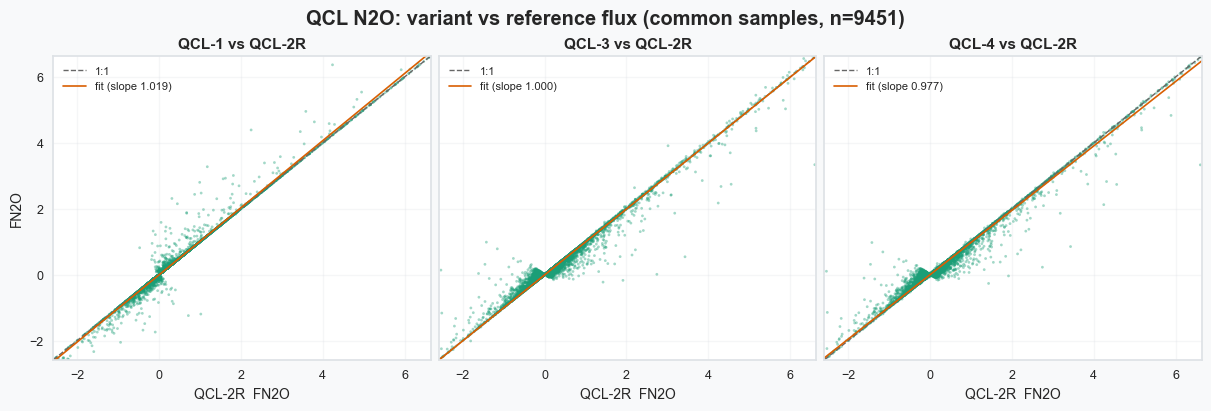

Saved ..\figures\04_regression_qcl_ch4.png


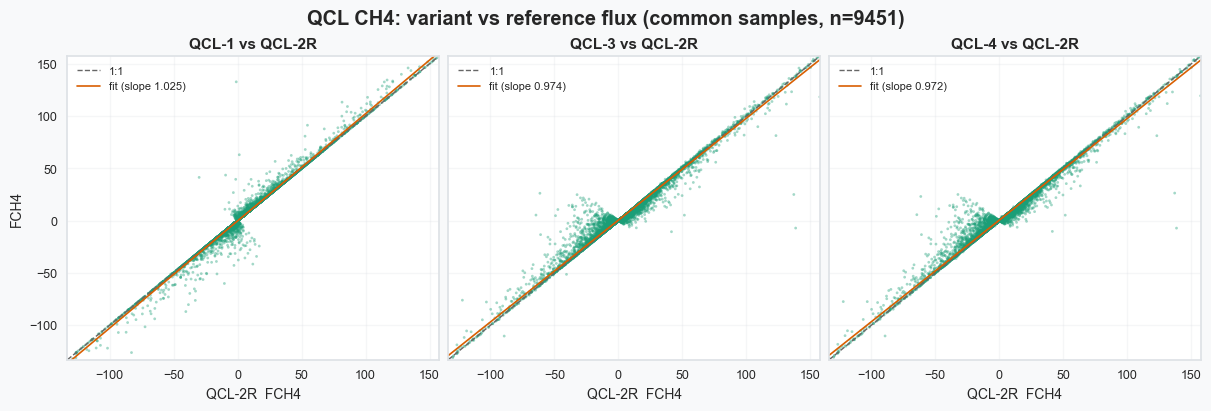

Saved ..\figures\04_regression_lgr_n2o.png


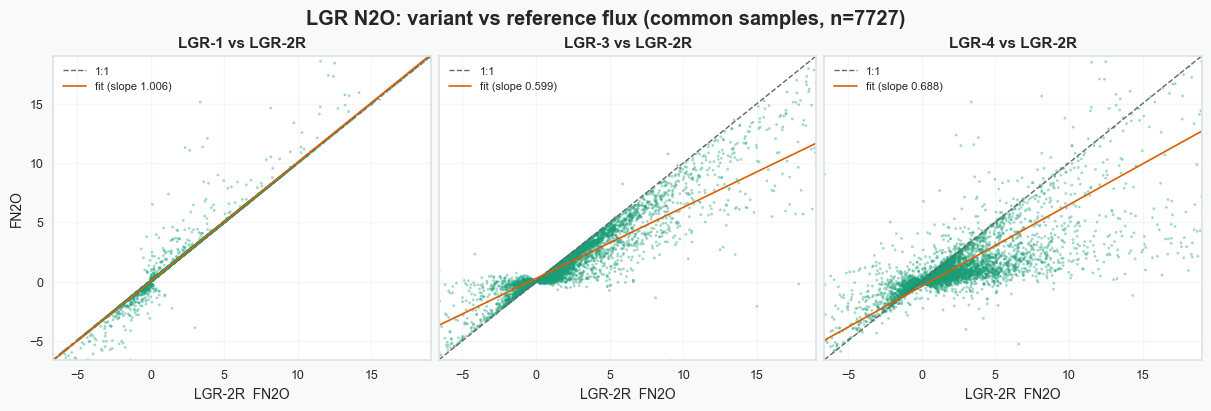

Saved ..\figures\04_regression_lgr_ch4.png


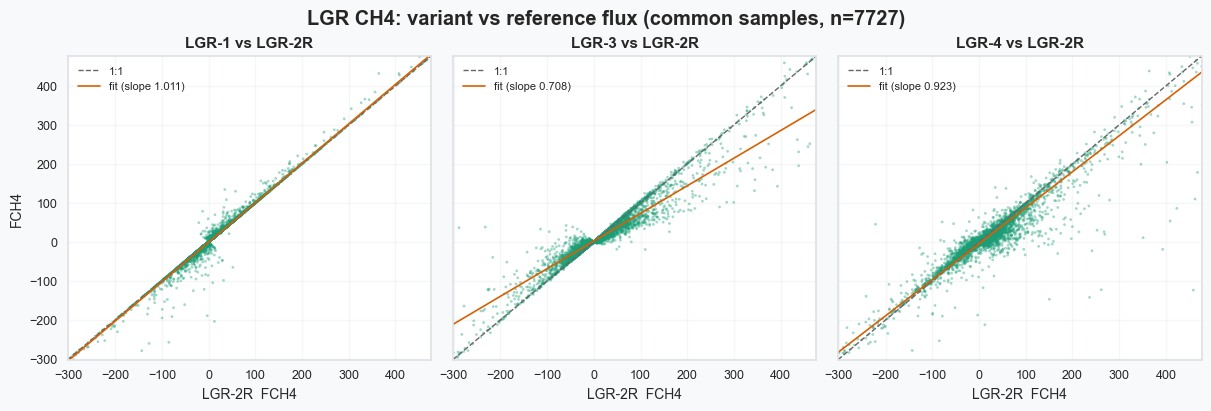

In [6]:
PCTL = (1, 99)  # robust axis range so a few outliers do not dominate the scatter

for analyzer, codes in ANALYZERS.items():
    ref = f"{analyzer}-{REF_SUFFIX}"
    others = [c for c in codes if c != ref]
    for gas, fluxvar in GASES.items():
        common = common_sets[(analyzer, gas)]
        r = common[ref]
        lo, hi = np.nanpercentile(common.to_numpy(), PCTL)

        fig, axes = plt.subplots(1, len(others), figsize=(4 * len(others), 4),
                                 sharex=True, sharey=True, constrained_layout=True)
        for ax, code in zip(np.atleast_1d(axes), others):
            x = common[code]
            ax.scatter(r, x, s=4, alpha=0.4, color="#1b9e77", edgecolors="none")
            ax.plot([lo, hi], [lo, hi], color="0.4", lw=1, ls="--", label="1:1")
            slope, intercept = np.polyfit(r, x, 1)
            xs = np.array([lo, hi])
            ax.plot(xs, slope * xs + intercept, color="#d95f02", lw=1.2,
                    label=f"fit (slope {slope:.3f})")
            ax.set_xlim(lo, hi)
            ax.set_ylim(lo, hi)
            ax.set_title(f"{code} vs {ref}", fontweight="bold")
            ax.set_xlabel(f"{ref}  {fluxvar}")
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8, loc="upper left")
        np.atleast_1d(axes)[0].set_ylabel(fluxvar)
        fig.suptitle(f"{analyzer} {gas}: variant vs reference flux "
                     f"(common samples, n={common.shape[0]})", fontweight="bold")
        out = FIGDIR / f"04_regression_{analyzer.lower()}_{gas.lower()}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print(f"Saved {out}")
        plt.show()

## Cumulative flux (overall budget)

The running sum of the flux over the common samples, one line per variant. This
is the most direct picture of how the lag setting changes the overall flux: lines
that fan apart over time mean the choice of lag accumulates into a different total
budget.

Saved ..\figures\04_cumulative_qcl_n2o.png


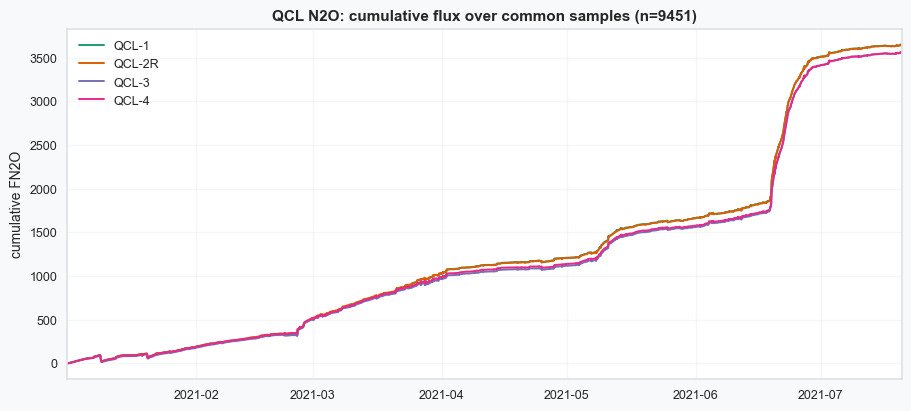

Saved ..\figures\04_cumulative_qcl_ch4.png


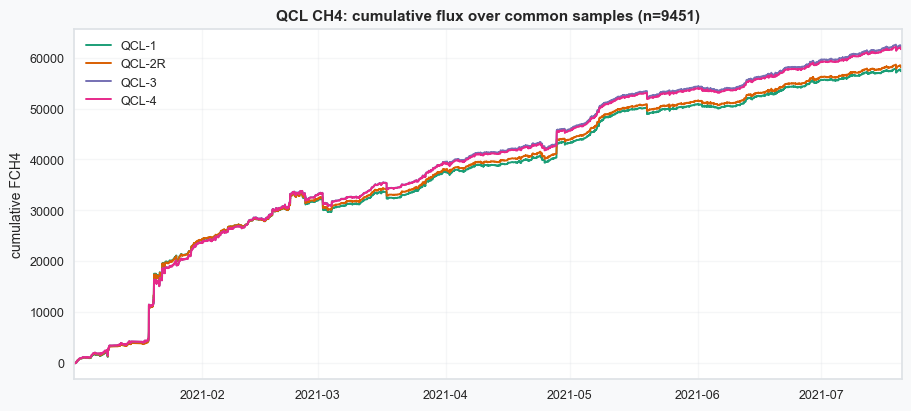

Saved ..\figures\04_cumulative_lgr_n2o.png


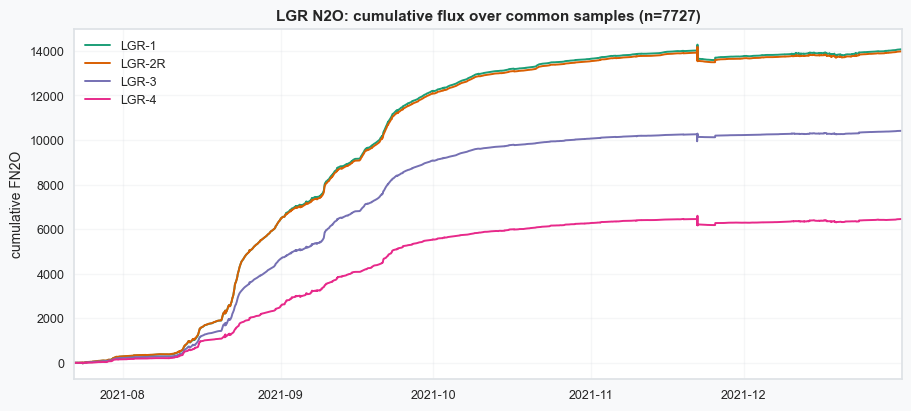

Saved ..\figures\04_cumulative_lgr_ch4.png


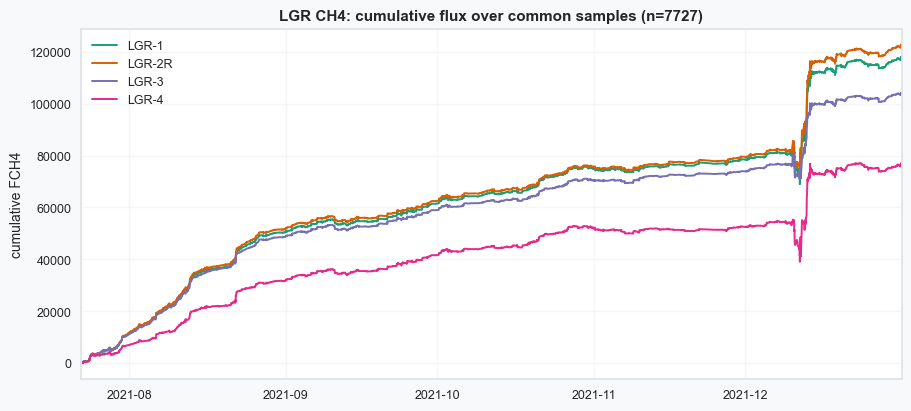

In [7]:
# Distinct color per variant suffix.
VAR_COLORS = {"-1": "#1b9e77", "-2R": "#d95f02", "-3": "#7570b3", "-4": "#e7298a"}

for analyzer, codes in ANALYZERS.items():
    for gas, fluxvar in GASES.items():
        common = common_sets[(analyzer, gas)]
        cum = common.cumsum()
        fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
        for code in codes:
            suffix = "-" + code.split("-", 1)[1]
            ax.plot(cum.index, cum[code], lw=1.4, color=VAR_COLORS.get(suffix), label=code)
        ax.set_xlim(cum.index.min(), cum.index.max())
        ax.set_title(f"{analyzer} {gas}: cumulative flux over common samples "
                     f"(n={common.shape[0]})", fontweight="bold")
        ax.set_ylabel(f"cumulative {fluxvar}")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        out = FIGDIR / f"04_cumulative_{analyzer.lower()}_{gas.lower()}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print(f"Saved {out}")
        plt.show()

## Runtime

In [8]:
NB_END = datetime.now()
print(f"Start:    {NB_START:%Y-%m-%d %H:%M:%S}")
print(f"End:      {NB_END:%Y-%m-%d %H:%M:%S}")
print(f"Runtime:  {NB_END - NB_START}")

Start:    2026-06-15 12:47:36
End:      2026-06-15 12:47:43
Runtime:  0:00:07.018244
